In [ ]:
import torch
print(torch.cuda.is_available())
device = torch.device("cuda")

True


In [ ]:
d = 128
sigma = 1

B = sigma * torch.randn(d, 2).to(device)

In [ ]:
# Task 1
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

N_f = 10000
N_b = 200
N_i = 100

x_f = (2*torch.rand(N_f,1)-1).detach().requires_grad_(True)
t_f = torch.rand(N_f,1).detach().requires_grad_(True)


t_b = torch.rand(N_b//2,1)

x_b0 = -torch.ones_like(t_b)
x_b1 = torch.ones_like(t_b)

x_i = (2*torch.rand(N_i,1)-1)
t_i = torch.zeros_like(x_i)

u_i = -torch.sin(np.pi*x_i)

x_f = x_f.to(device)
t_f = t_f.to(device)

x_b0 = x_b0.to(device)
x_b1 = x_b1.to(device)
t_b = t_b.to(device)

x_i = x_i.to(device)
t_i = t_i.to(device)
u_i = u_i.to(device)

d = 128
sigmas = [1,10]
all_losses = {}
for sigma in sigmas:
  B = sigma * torch.randn(d, 2, device=device)



  class PINN(nn.Module):

      def __init__(self, B):
          super().__init__()
          self.register_buffer("B", B)
          self.net = nn.Sequential(
              nn.Linear(2*d, 100),
              nn.Tanh(),

              nn.Linear(100,100),
              nn.Tanh(),

              nn.Linear(100,100),
              nn.Tanh(),

              nn.Linear(100,100),
              nn.Tanh(),

              nn.Linear(100,1)
          )

      def forward(self, x, t):
          XT = torch.cat([x,t], dim=1)
          v = XT @ self.B.T

          embedding = torch.cat(
              [torch.sin(v), torch.cos(v)],
              dim=1
          )
          return self.net(embedding)

  model = PINN(B).to(device)


  print(torch.cuda.is_available())
  print(next(model.parameters()).device)
  print(x_f.device)

  nu = 0.01/np.pi

  def pde_residual(model,x,t):
      u = model(x,t)
      u_x = torch.autograd.grad(u,x,grad_outputs=torch.ones_like(u),create_graph=True)[0]
      u_t = torch.autograd.grad(u,t,grad_outputs=torch.ones_like(u),create_graph=True)[0]
      u_xx = torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]
      f = u_t + u*u_x - nu*u_xx
      return f

  optimizer = torch.optim.Adam(
      model.parameters(),
      lr=1e-3
  )

  losses = []
  all_losses[sigma] = losses


  for epoch in range(10000):
      optimizer.zero_grad()

      f = pde_residual(model,x_f,t_f)
      loss_f = torch.mean(f**2)

      u_b0 = model(x_b0,t_b)
      u_b1 = model(x_b1,t_b)

      loss_b = (torch.mean(u_b0**2)+torch.mean(u_b1**2))
      u_pred_i = model(x_i,t_i)
      loss_i = ((u_pred_i-u_i)**2).mean()
      loss = loss_f + loss_b + loss_i

      loss.backward()
      optimizer.step()

      losses.append(loss.item())

      if epoch % 1000 == 0:
          print(epoch, loss.item())


  plt.figure(figsize=(6,4))
  plt.plot(losses)
  plt.yscale("log")
  plt.xlabel("Epoch")
  plt.ylabel(f"Loss(sigma:{sigma})")
  plt.title("Training Loss")
  plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import scipy.io

data = scipy.io.loadmat("burgers_shock.mat")

x = data["x"]
t = data["t"]
usol = data["usol"]

In [ ]:
import copy

fourier_model = copy.deepcopy(model)

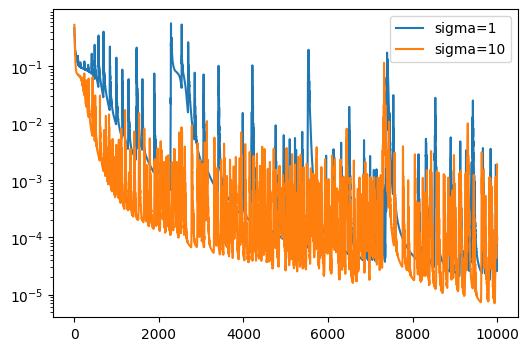

In [ ]:

plt.figure(figsize=(6,4))
for sigma in sigmas:
    plt.plot(all_losses[sigma], label=f"sigma={sigma}")

plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
class PINN_v(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,1)
        )

    def forward(self,x,t):
        XT = torch.cat([x,t],dim=1)
        return self.net(XT)

# Task 2(using Vanilla PINN)
model = PINN_v().to(device)
losses_v = []
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)
lambda_bc_list = []
lambda_ic_list = []


def gradient_norm(loss, parameters):
  model.zero_grad()
  loss.backward(retain_graph=True)
  grad_norm = 0.0
  for p in parameters:
      if p.grad is not None:
          grad_norm += p.grad.norm(2).item()**2

  grad_norm = grad_norm**0.5
  return grad_norm



for epoch in range(10000):

    f = pde_residual(model,x_f,t_f)
    loss_f = torch.mean(f**2)

    u_b0 = model(x_b0,t_b)
    u_b1 = model(x_b1,t_b)

    loss_b = (torch.mean(u_b0**2)+torch.mean(u_b1**2))
    u_pred_i = model(x_i,t_i)
    loss_i = ((u_pred_i-u_i)**2).mean()

    # Compute gradient norms for each loss component
    grad_pde = gradient_norm(loss_f, model.parameters())
    grad_bc  = gradient_norm(loss_b,  model.parameters())
    grad_ic  = gradient_norm(loss_i,  model.parameters())

    # Rescale so all components contribute equally
    mean_grad = (grad_pde + grad_bc + grad_ic) / 3
    eps = 1e-8

    lambda_bc = mean_grad/(grad_bc+eps)
    lambda_ic = mean_grad/(grad_ic+eps)

    lambda_bc_list.append(lambda_bc)
    lambda_ic_list.append(lambda_ic)

    optimizer.zero_grad()

    loss = loss_f + lambda_bc*loss_b + lambda_ic*loss_i

    loss.backward()
    optimizer.step()

    losses_v.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())


plt.figure(figsize=(6,4))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

print(lambda_bc_list)
print(lambda_ic_list)

In [ ]:
gradnorm_model = copy.deepcopy(model)

0 0.4327833354473114
1000 0.08391338586807251
2000 0.07139906287193298
3000 0.030910298228263855
4000 0.0042707244865596294
5000 0.0019536809995770454
6000 0.002452863147482276
7000 0.0025935336016118526
8000 0.0006276451167650521
9000 0.0006838059052824974


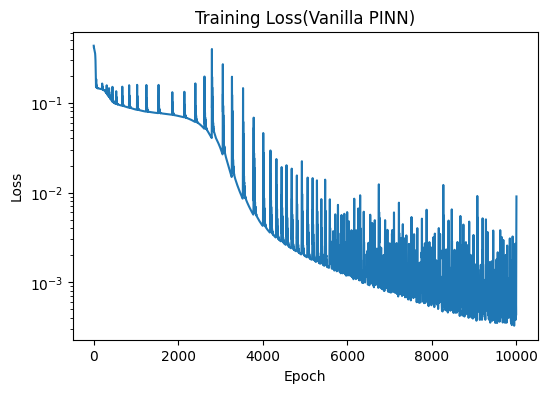

In [ ]:
model = PINN_v().to(device)
losses=[]
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

for epoch in range(10000):
    optimizer.zero_grad()

    f = pde_residual(model,x_f,t_f)
    loss_f = torch.mean(f**2)

    u_b0 = model(x_b0,t_b)
    u_b1 = model(x_b1,t_b)

    loss_b = (torch.mean(u_b0**2)+torch.mean(u_b1**2))
    u_pred_i = model(x_i,t_i)
    loss_i = ((u_pred_i-u_i)**2).mean()
    loss = loss_f + loss_b + loss_i

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss(Vanilla PINN)")
plt.show()

In [ ]:
vanilla_model = copy.deepcopy(model)

In [ ]:
X, T = np.meshgrid(
    x.flatten(),
    t.flatten(),
    indexing="ij"
)

U_exact = usol
X_flat = X.reshape(-1,1)
T_flat = T.reshape(-1,1)

X_test = torch.tensor(
    X_flat,
    dtype=torch.float32,
    device=device
)

T_test = torch.tensor(
    T_flat,
    dtype=torch.float32,
    device=device
)
models=[gradnorm_model,fourier_model,vanilla_model]
L2_error=[]
for model in models:
  with torch.no_grad():
      U_pred = model(X_test, T_test).cpu().numpy()

  U_pred = U_pred.reshape(X.shape)

  L2_error.append(np.linalg.norm(U_pred - U_exact) / np.linalg.norm(U_exact))


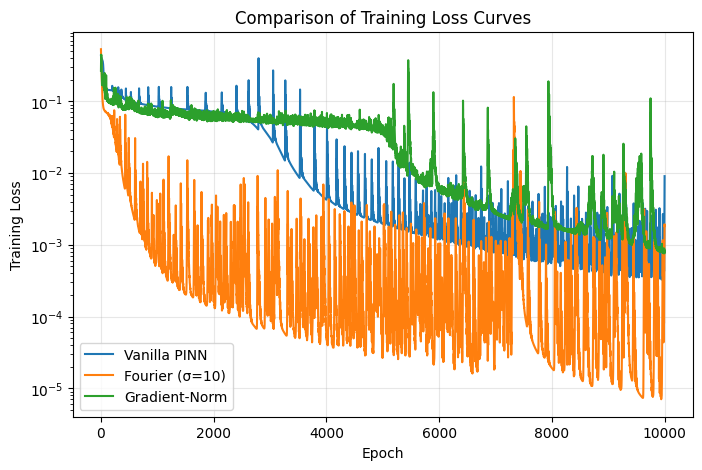

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(losses, label="Vanilla PINN")
plt.plot(all_losses[10], label="Fourier (σ=10)")
plt.plot(losses_v, label="Gradient-Norm")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Comparison of Training Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
df = pd.DataFrame([
    ["Vanilla PINN", L2_error[2]],
    ["Fourier (σ=10)", L2_error[1]],
    ["Gradient-Norm", L2_error[0]],
], columns=["Method", "Final L2 Relative Error"])

display(df)

,Method,Final L2 Relative Error
0,Vanilla PINN,0.074164
1,Fourier (σ=10),0.027456
2,Gradient-Norm,0.043748


In [ ]:
#Task 4

#Q1
#Among the three methods the Fourier feature model worked the best. It had the L² relative error of 0.0275.
#The gradient-norm loss balancing method came next with an error of 0.0437.The vanilla PINN had the error of 0.0742.This result makes sense.
#The Fourier feature model uses basis functions to enrich the input data. This helps the network capture the high-frequency parts of the Burgers equation solution accurately.
#The Fourier feature model did a good job. The gradient-norm loss balancing method also worked better.
#It reduced the imbalance between loss terms. However its improvement was not as big, as that of the Fourier feature model.
#The gradient-norm loss balancing method is still useful. It helps to improve the performance. The Fourier feature model and gradient-norm loss balancing method both performed well. The vanilla PINN did not do well.

#Q2
#In the vanilla PINN, the PDE loss gradient L_pde was the largest among the three loss components. This indicates that the optimizer is primarily driven by minimizing the PDE residual,
#while the boundary-condition and initial-condition losses contribute much smaller gradients